In [1]:
# Necessary packages to run this file:
import spectral
import spectral.io.envi as envi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
#import matplotlib.image as img
from ipywidgets import interact, interactive, fixed, interact_manual
#import ipywidgets as widgets
#from IPython.display import display
from scipy.ndimage import gaussian_filter
from skimage.restoration import richardson_lucy
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
#from sklearn.linear_model import SGDClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_absolute_error,mean_squared_error
import tensorflow as tf

I0000 00:00:1785827592.989017 1673371 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785827593.047906 1673371 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Helper functions:

In [2]:
def get_file_paths(base_path):
    folders = sorted([
        f for f in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, f))])
    file_numbers = []
    for f in folders:
        for l in os.listdir(base_path+f+'/metadata/'):
            if l.endswith('.xml'):
                file_numbers.append(str(l.replace('.xml', '')))
    if int(len(folders)) != int(len(file_numbers)):
        print("Warning: couldn't find all file numbers; returning empty arrays.")
        return [], []
    return folders, file_numbers


# TODO: generalisoi
# Returns two arrays: first one with the folder path "kitchen[day2]/[object]" and the second with the corresponding file number.
def get_all_file_paths(path):
    folders1, nums1 = get_file_paths(path+'kitchen/')
    ind = [folders1.index('sekoite1'), folders1.index('sekoite2')]
    del folders1[ind[0]:ind[1]+1]
    del nums1[ind[0]:ind[1]+1]
    for i, folder in enumerate(folders1):
        folders1[i] = 'kitchen/'+folder+'/'
    folders2, nums2 = get_file_paths(path+'kitchenday2/')
    ind = [folders2.index('sekoitus3'), folders2.index('sekoitus4')]
    del folders2[ind[0]:ind[1]+1]
    del nums2[ind[0]:ind[1]+1]
    for i, folder in enumerate(folders2):
        folders2[i] = 'kitchenday2/'+folder+'/'
    return folders1 + folders2, nums1 + nums2


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def open_image(file_path):
    try:
        image = envi.open(file_path)
        data = image.load()

        wavelengths = image.metadata.get('wavelength', None)
        if wavelengths:
            wavelengths = [float(w) for w in wavelengths]

        return data, wavelengths

    except Exception as e:
        print(f"  Error loading {file_path}: {e}")
        return None, None


# Data on nyt kuutio.
# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def load_and_compute_reflectance(path, folder_name, file_number):
    folder_path = path + folder_name + '/capture/'
    paths = {
        'raw':   os.path.join(folder_path, f"{file_number}.hdr"),
        'white': os.path.join(folder_path, f"WHITEREF_{file_number}.hdr"),
        'dark':  os.path.join(folder_path, f"DARKREF_{file_number}.hdr"),
    }

    for key, p in paths.items():
        if not os.path.isfile(p):
            print(f"  Missing {key} file: {p}")
            return None, None

    raw, wavelengths = open_image(paths['raw'])
    white, _ = open_image(paths['white'])
    dark, _  = open_image(paths['dark'])

    if any(x is None for x in [raw, white, dark]):
        print("  Failed to load one or more image cubes.")
        return None, None
    
    denominator = white - dark
    denominator[denominator == 0] = 1e-6

    # np.clip: limits the values between given given values, here 0 and 1
    reflectance = np.clip((raw - dark) / denominator, 0, 1)
    return reflectance, wavelengths


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def create_sample_mask(cube, band=None):
    if band is None:
        #band = 130
        #band = int(cube.shape[2]/2)
        band = min_max_reflectance(cube)[2]

    img = cube[:, :, band]
    img_u8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    # Original:
    #_, mask = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    blur = cv2.GaussianBlur(img_u8,(5,5),0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    #plt.imshow(mask)
    #plt.show()
    return mask


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def segment_sample(cube, mask, margin=5, roi_mode="single", min_roi_area=50):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("  Warning: no contours found; returning original image.")
        return cube.copy(), mask.copy()

    # Sort by area (largest first)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    roi_mask = np.zeros_like(mask, dtype=np.uint8)

    if roi_mode == "single":
        # Keep the largest contour whose polygon approximation has >= 5 vertices
        for c in contours:
            if len(cv2.approxPolyDP(c, 3, True)) >= 5:
                cv2.fillPoly(roi_mask, [c], 255)
                break
        else:
            # Fallback: use the largest contour regardless
            cv2.fillPoly(roi_mask, [contours[0]], 255)

    elif roi_mode == "multiple":
        for c in contours:
            if cv2.contourArea(c) >= min_roi_area:
                cv2.fillPoly(roi_mask, [c], 255)
    else:
        raise ValueError(f"roi_mode must be 'single' or 'multiple', got '{roi_mode}'")

    # Apply mask (element-wise multiply is correct for float arrays)
    filtered = cube * (roi_mask[:, :, np.newaxis] / 255.0)

    # Crop to bounding box of the combined mask
    # Rajaa kuvan vain maskiin.
    coords = cv2.findNonZero(roi_mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        x = max(0, x - margin)
        y = max(0, y - margin)
        w = min(cube.shape[1] - x, w + 2 * margin)
        h = min(cube.shape[0] - y, h + 2 * margin)
        segmented = filtered[y:y+h, x:x+w]
        roi_mask  = roi_mask[y:y+h, x:x+w]
    else:
        segmented = filtered

    return segmented, roi_mask


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def extract_mean_spectrum(cube, mask):
    pixels = cube[mask > 0]
    if pixels.size == 0:
        print("  Warning: mask is empty; returning zeros.")
        return np.zeros(cube.shape[2])
    return np.mean(pixels, axis=0)


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def min_max_reflectance(cube):
    min = int(np.argmin(np.mean(cube, axis=(0, 1))))
    max = int(np.argmax(np.mean(cube, axis=(0, 1))))
    li = np.mean(cube, axis=(0, 1))
    li.sort()
    mid = len(li)//2
    return min, max, mid


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def gaussian_psf(size=5, sigma=1.0):
    psf = np.zeros((size, size))
    psf[size // 2, size // 2] = 1.0
    psf = gaussian_filter(psf, sigma=sigma)
    return psf / psf.sum()


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def apply_richardson_lucy(image, psf, num_iter=15):
    result = np.zeros_like(image)
    for b in range(image.shape[2]):
        result[:, :, b] = richardson_lucy(image[:, :, b], psf, num_iter=num_iter)
    return result


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def process_sample(path, folder_name, file_number, roi_mode="single", min_roi_area=50, margin=5, deblur=False, deblur_sigma=0.1, deblur_iter=5, visualize=False):
    cube, waves = load_and_compute_reflectance(path, folder_name, file_number)

    if deblur:
        psf = gaussian_psf(sigma=deblur_sigma)
        processed = apply_richardson_lucy(cube, psf, num_iter=deblur_iter)
        if visualize:
            visualize_step(cube, processed, title=f"Deblurring — {folder_name}")
    else:
        processed = cube

    mask = create_sample_mask(processed)
    if visualize:
        plt.imshow(mask, cmap='gray')
        plt.title('Binary mask')
        plt.axis('off')
        plt.show()

    segmented, roi_mask = segment_sample(
        processed, mask, margin=margin,
        roi_mode=roi_mode, min_roi_area=min_roi_area,
    )
    
    plt.imshow(roi_mask)
    plt.show()

    spectrum = extract_mean_spectrum(segmented, roi_mask)

    #visualize_step(cube, segmented)

    return spectrum, waves


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def visualize_step(original, processed, band=None, title=""):
    if band is None:
        band = min_max_reflectance(original)[1]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(original[:, :, band], cmap='gray')
    ax1.set_title('Before')
    ax1.axis('off')
    fig.colorbar(im1, ax=ax1)

    im2 = ax2.imshow(processed[:, :, band], cmap='gray')
    ax2.set_title('After')
    ax2.axis('off')
    fig.colorbar(im2, ax=ax2)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def plot_spectra(wavelengths, raw, corrected, title="", save_path=False, legends=None):
    raw = np.array(raw)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.plot(wavelengths, raw.T, alpha=0.6)
    #ax1.legend(legends, loc = 'lower left')
    ax1.set_ylabel('Reflectance (a.u.)')
    ax1.set_title('Original spectra')
    ax1.grid(True, alpha=0.3)

    ax2.plot(wavelengths, corrected.T, alpha=0.6)
    #ax2.legend(legends, loc = 'lower left')
    ax2.set_xlabel('Wavelength (nm)')
    ax2.set_ylabel('Reflectance (a.u.)')
    ax2.set_title('MSC-corrected spectra')
    ax2.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def multiplicative_scatter_correction(spectra, reference=None):
    if reference is None:
        reference = np.mean(spectra, axis=0)

    corrected = np.zeros_like(spectra)
    for i in range(len(spectra)):
        coeffs = np.polyfit(reference, spectra[i], 1)
        corrected[i] = (spectra[i] - coeffs[1]) / coeffs[0]

    return corrected, reference

Define the path to the `everyday_objects`-data.

In [3]:
PATH = '/n/archive/labs/hsi-data/everyday_objects/'

Retrieve the folder paths and file numbers.

In [4]:
folders, nums = get_all_file_paths(PATH)

print(folders, nums)

['kitchen/basmatiriisi/', 'kitchen/kaurahiutale1min/', 'kitchen/kuivahiiva/', 'kitchen/kvinoa/', 'kitchen/ohrahiutale_kasittelematon/', 'kitchen/psyllium/', 'kitchen/puuroriisi/', 'kitchen/rikottu_ohrasuurimo/', 'kitchen/seesaminsiemen/', 'kitchenday2/durumvehna/', 'kitchenday2/jodioitu_suola/', 'kitchenday2/karkea_vehnajauho/', 'kitchenday2/kookoshiutale/', 'kitchenday2/leivinjauhe/', 'kitchenday2/maizena/', 'kitchenday2/merisuola/', 'kitchenday2/perunajauho/', 'kitchenday2/puolikarkea_vehnajauho/', 'kitchenday2/raesokeri/', 'kitchenday2/sampylajauho/', 'kitchenday2/sokeri/', 'kitchenday2/sooda/', 'kitchenday2/tomusokeri/'] ['040', '037', '042', '035', '038', '043', '041', '036', '044', '067', '069', '059', '057', '065', '061', '068', '063', '062', '066', '060', '070', '064', '058']


In [5]:
cubes = []
for i, folder in enumerate(folders):
    cube, _ = load_and_compute_reflectance(PATH, folder, nums[i])
    cubes.append(cube)

def interactive_pic(cube, layer):
    for i, folder in enumerate(folders):
        if cube == folder:
            c = cubes[i]
    plt.imshow(c[:,:,layer])
    plt.show()

interact(interactive_pic, cube=folders, layer=(0, 203, 1))

/tmp/ipykernel_1673371/2832898514.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_1673371/2832898514.py:78: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


interactive(children=(Dropdown(description='cube', options=('kitchen/basmatiriisi/', 'kitchen/kaurahiutale1min…

<function __main__.interactive_pic(cube, layer)>

Processing the samples:

Found 23 sample(s)

[1/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/capture/


/tmp/ipykernel_1673371/2832898514.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_1673371/2832898514.py:78: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


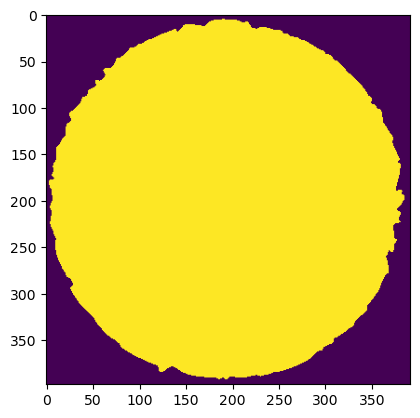

[2/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/kaurahiutale1min/capture/


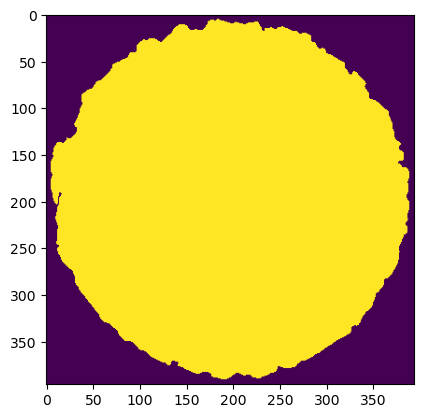

[3/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/kuivahiiva/capture/


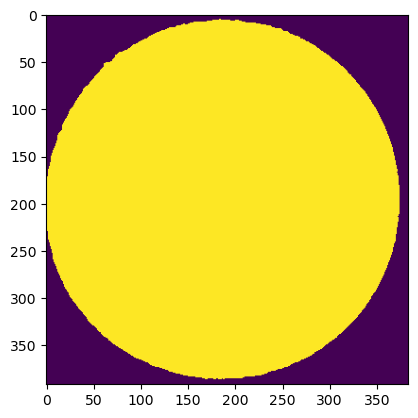

[4/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/kvinoa/capture/


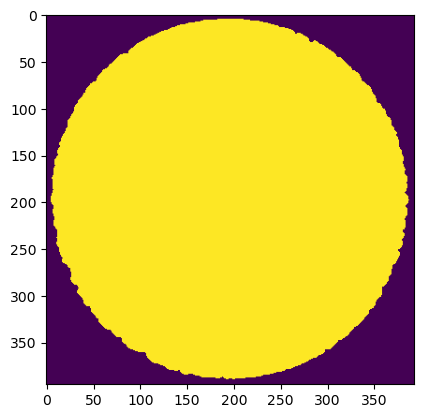

[5/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/ohrahiutale_kasittelematon/capture/


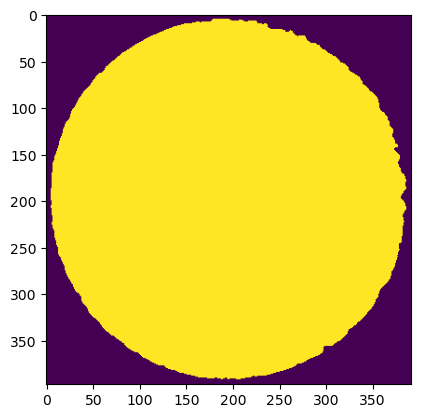

[6/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/psyllium/capture/


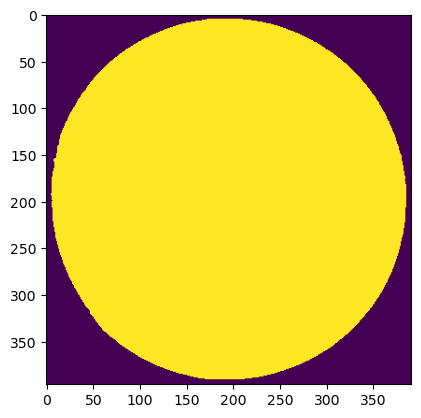

[7/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/puuroriisi/capture/


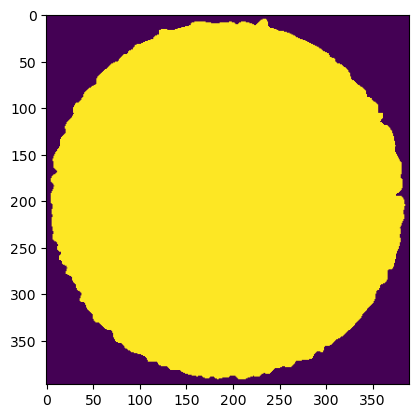

[8/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/rikottu_ohrasuurimo/capture/


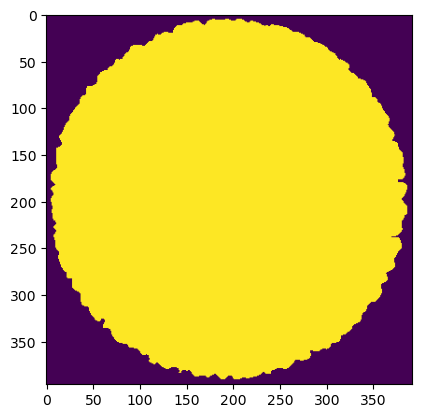

[9/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/seesaminsiemen/capture/


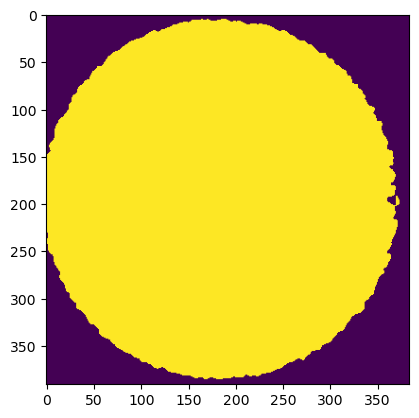

[10/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/durumvehna/capture/


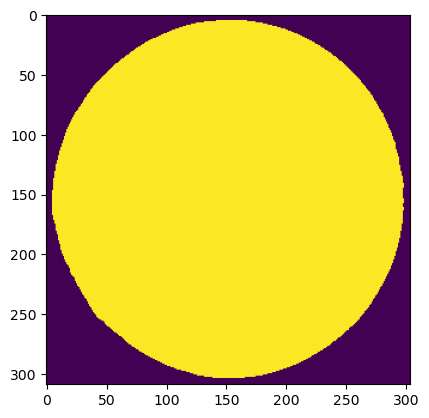

[11/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/jodioitu_suola/capture/


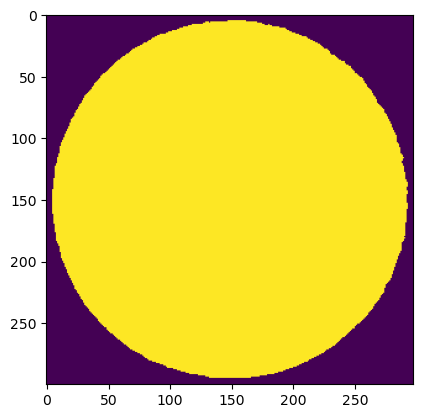

[12/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/karkea_vehnajauho/capture/


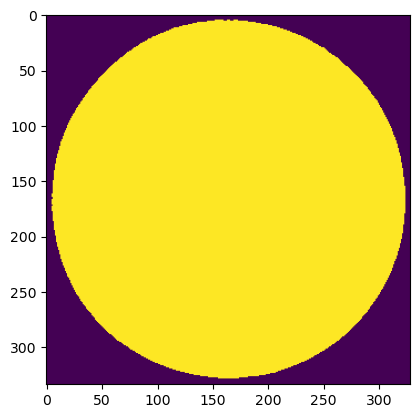

[13/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/kookoshiutale/capture/


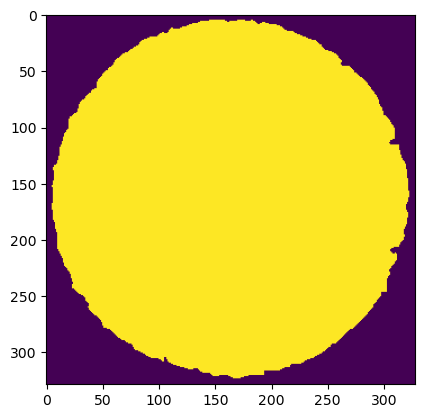

[14/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/leivinjauhe/capture/


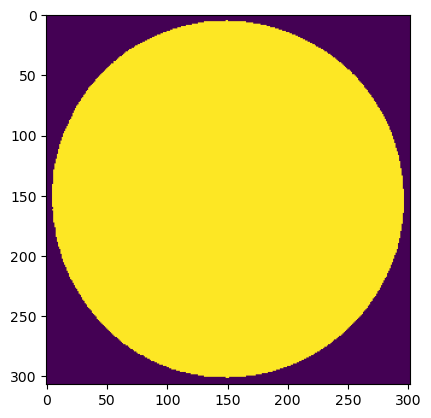

[15/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/maizena/capture/


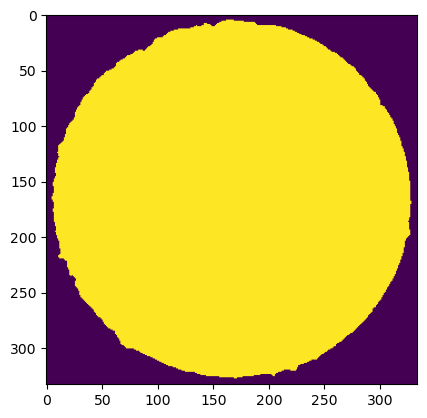

[16/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/merisuola/capture/


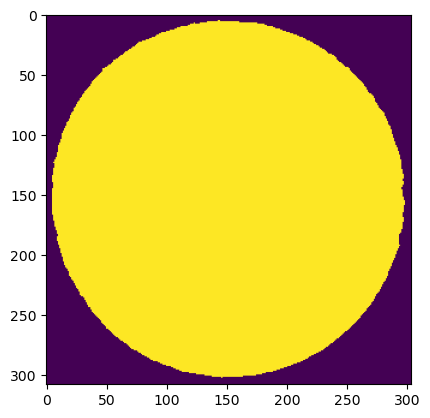

[17/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/perunajauho/capture/


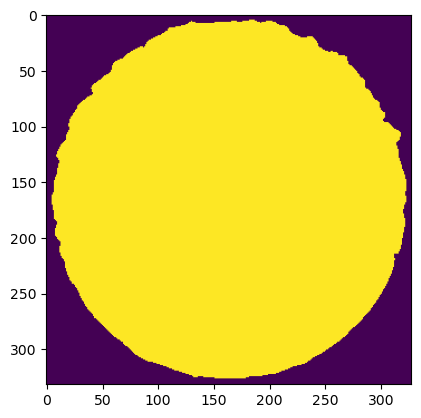

[18/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/puolikarkea_vehnajauho/capture/


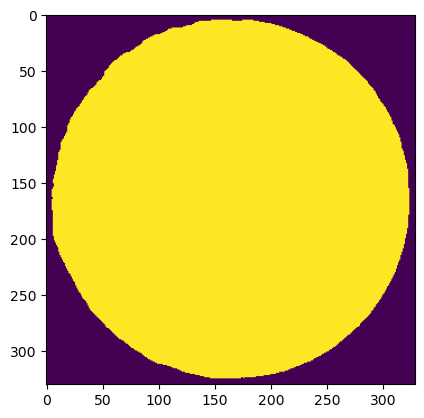

[19/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/raesokeri/capture/


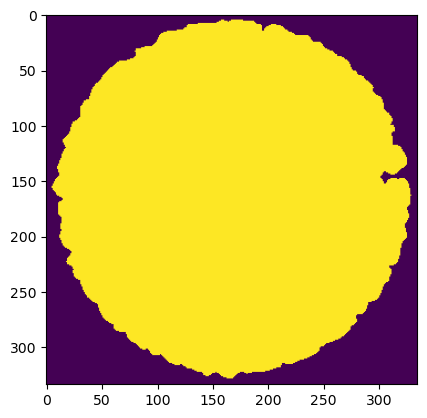

[20/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/sampylajauho/capture/


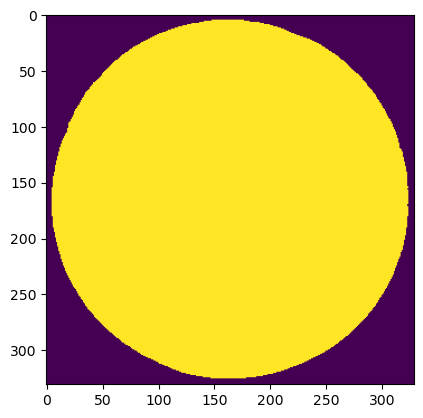

[21/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/sokeri/capture/


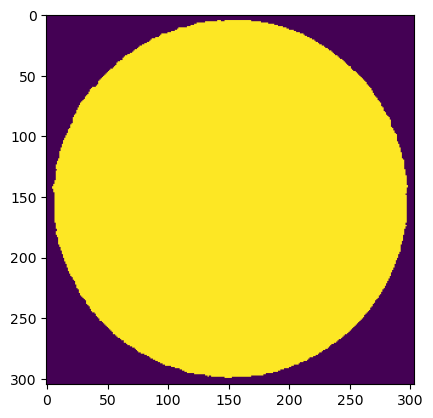

[22/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/sooda/capture/


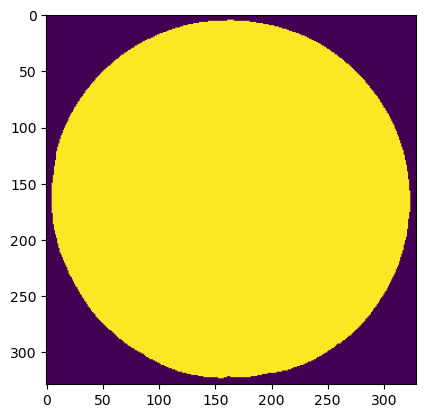

[23/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/tomusokeri/capture/


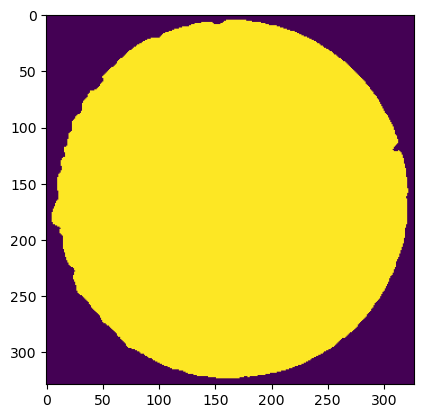


Processed 23/23 samples successfully.
There are 204 spectral bands in the cubes.


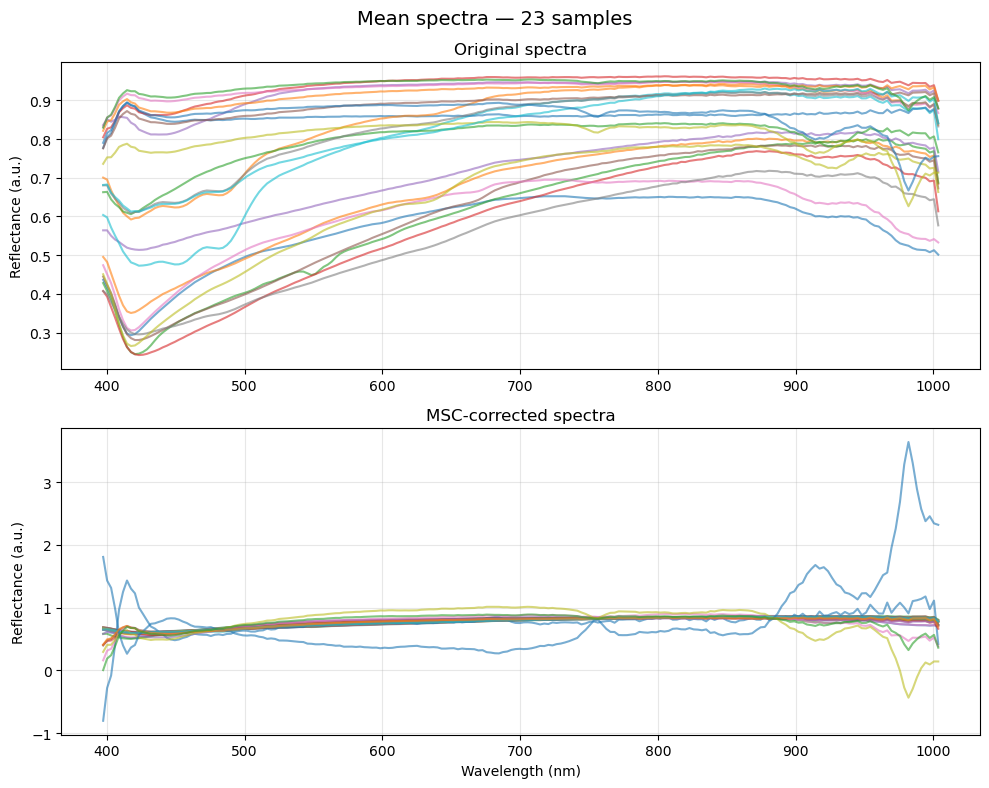

In [6]:
print(f"Found {len(folders)} sample(s)\n")

spectra, names = [], []
wavelengths = None

for i, folder in enumerate(folders, 1):
    print(f"[{i}/{len(folders)}] ", end="")
    capture = os.path.join(PATH, folder, "capture/")
    print(capture)

    if not os.path.isdir(capture):
        print(f"  Skipping {folder}: no 'capture' subfolder.")
        continue

    spec, wl = process_sample(PATH, folder, nums[i-1])
    if spec is not None:
        spectra.append(spec)
        names.append(folder)
        if wavelengths is None:
            wavelengths = wl

spectra_msc, ref_spectrum = multiplicative_scatter_correction(spectra)


print(f"\nProcessed {len(spectra)}/{len(folders)} samples successfully.")

print(f"There are {len(wavelengths)} spectral bands in the cubes.")

plot_spectra(wavelengths, spectra, spectra_msc, title=f"Mean spectra — {len(names)} samples", legends=folders)

In [7]:
os.listdir('/n/archive/labs/hsi-data/everyday_objects/kitchen/sekoite1/capture')
#(os.path.getsize('/n/archive/labs/hsi-data/everyday_objects/kitchen/sekoite2/capture/056.raw')/1024)/1024

['WHITEDARKREF_055.raw',
 'DARKREF_055.hdr',
 'WHITEREF_055.raw',
 '055.hdr',
 'WHITEDARKREF_055.hdr',
 'WHITEREF_055.hdr',
 'DARKREF_055.raw',
 '055.raw']

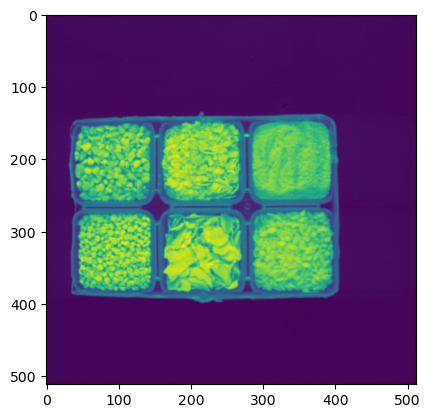

In [7]:
data_raw = spectral.envi.open('/n/archive/labs/hsi-data/everyday_objects/kitchen/sekoite2/capture/056.hdr')

cube_raw = np.array(data_raw.asarray())

'''
i = 1

for p in range(0, i):
    plt.subplot(1, i+1, p+1)
    plt.imshow(cube_raw[:,:,int(p*(204/i))])
    plt.axis('off')
'''
plt.imshow(cube_raw[:,:,150])
plt.show()

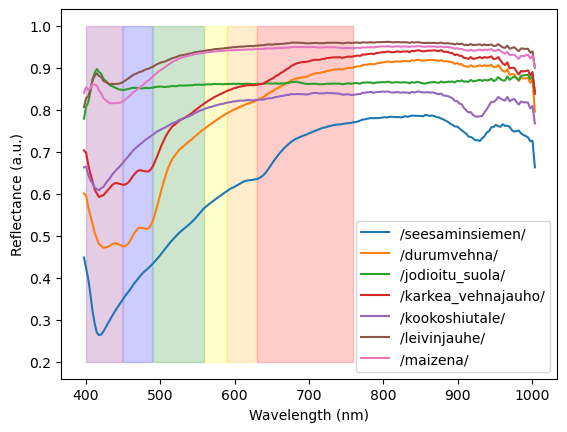

In [19]:
[plt.plot(wavelengths, a) for a in averages[8:-8]]
plt.fill_between(np.arange(400,450), 0.2, 1, color='purple', alpha=0.2)
plt.fill_between(np.arange(450,490), 0.2, 1, color='blue', alpha=0.2)
plt.fill_between(np.arange(490,560), 0.2, 1, color='green', alpha=0.2)
plt.fill_between(np.arange(560,590), 0.2, 1, color='yellow', alpha=0.2)
plt.fill_between(np.arange(590,630), 0.2, 1, color='orange', alpha=0.2)
plt.fill_between(np.arange(630,760), 0.2, 1, color='red', alpha=0.2)
legs = [s[s.index('/'):] for s in folders]
plt.legend(legs[8:-8])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance (a.u.)')
plt.show()

# Spectral analysis

Muuttujat:
- PATH : string
    - `everyday_objects`-datan polku
- spectra : list
    - Käytettyjen kuvien spektrit
- names : list
    - Käytettyjen kansioiden nimet
- wavelengths : list
    - Aallonpituudet
- spectra_msc : numpy.ndarray
    - MSC-käsitellyt spektrit
- ref_spectrum : numpy.ndarray

In [7]:
reflectance, wavelengths = load_and_compute_reflectance(PATH, folders[0], nums[0])
mask = create_sample_mask(reflectance)
segmented, roi_mask = segment_sample(reflectance, mask)
type(segmented)

/tmp/ipykernel_1673371/2832898514.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_1673371/2832898514.py:78: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


numpy.ndarray

In [8]:
samples = 1000

names = []
pixels = []
averages = []

for n in range(len(folders)):
    cube, waves = load_and_compute_reflectance(PATH, folders[n], nums[n])
    mask = create_sample_mask(cube)
    segmented, roi_mask = segment_sample(cube, mask)
    i, j = np.nonzero(roi_mask)
    ix = np.random.choice(len(i), samples, replace=False)
    averages.append(segmented[i[ix], j[ix],:])
    pixels = [*pixels, *segmented[i[ix], j[ix],:]]
    names.extend([n for i in range(samples)])

pixels = np.array(pixels).T
averages = [np.mean(a, axis=0) for a in averages]

/tmp/ipykernel_1673371/2832898514.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_1673371/2832898514.py:78: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


In [9]:
df = pd.DataFrame(pixels.T, index=names, columns=wavelengths)
print(df)

     397.32    400.20    403.09    405.97    408.85    411.74    414.63   \
0   0.446809  0.423077  0.406780  0.366197  0.336957  0.312000  0.308571   
0   0.468085  0.423077  0.389830  0.352113  0.304348  0.256000  0.222857   
0   0.489362  0.442308  0.389830  0.352113  0.282609  0.240000  0.217143   
0   0.468085  0.461538  0.440678  0.408451  0.380435  0.346774  0.331429   
0   0.489362  0.480769  0.457627  0.422535  0.391304  0.360000  0.354286   
..       ...       ...       ...       ...       ...       ...       ...   
22  0.593750  0.571429  0.560976  0.540000  0.523077  0.511111  0.472441   
22  0.937500  1.000000  0.975610  0.980000  0.969231  0.977778  0.984252   
22  0.750000  0.742857  0.756098  0.800000  0.828125  0.822222  0.825397   
22  0.812500  0.828571  0.853659  0.820000  0.861538  0.900000  0.920635   
22  0.937500  0.942857  1.000000  0.980000  1.000000  1.000000  1.000000   

     417.52    420.40    423.29   ...   975.79    978.88    981.96    985.05   \
0   0.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    df, df.index, test_size=0.25, random_state=42
)

#print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

print(X_train.shape, type(X_train))
print(y_train.shape)

(17250, 204) <class 'numpy.ndarray'>
(17250,)


# Logistic regression

In [27]:
model = LogisticRegression(max_iter=2000, penalty=None, random_state=4, solver='newton-cg')
#print(model.get_params())
#model = svm.SVC()
#model = SGDClassifier(loss="hinge", penalty="l2", max_iter=500)

param_grid = {'max_iter':[2000, 3000, 4000], 'penalty':['l1', 'l2', 'elasticnet', None], 'solver':['lbfgs', 'newton-cg', 'newton-cholesky']}

#model = tree.DecisionTreeClassifier(random_state=4)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy: {round(accuracy,2)}")
print(classification_report(y_test, y_pred))

#grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, verbose=True)
#grid_search.fit(X_train, y_train)

#print("best accuracy", grid_search.best_score_)
#print(grid_search.best_estimator_)

accuracy: 0.94
              precision    recall  f1-score   support

         035       0.97      0.97      0.97       270
         036       0.93      0.93      0.93       253
         037       0.97      0.98      0.97       218
         038       0.94      0.93      0.93       254
         040       0.95      0.97      0.96       231
         041       0.98      0.95      0.96       259
         042       1.00      1.00      1.00       275
         043       1.00      1.00      1.00       248
         044       1.00      1.00      1.00       259
         057       1.00      1.00      1.00       262
         058       0.92      0.88      0.90       257
         059       0.94      0.98      0.96       256
         060       0.90      0.90      0.90       234
         061       0.93      0.94      0.93       231
         062       0.92      0.87      0.89       252
         063       0.88      0.92      0.90       238
         064       0.83      0.86      0.84       243
         065

In [12]:
mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
mse = mean_squared_error(y_true=y_test,y_pred=y_pred)

print("MAE:",mae)
print("MSE:",mse)

MAE: 0.24365217391304347
MSE: 2.457217391304348


In [21]:
sekoitteet = ['kitchen/sekoite1/', 'kitchen/sekoite2/', 'kitchenday2/sekoitus3/', 'kitchenday2/sekoitus4/']
s_nums = ['055', '056', '071', '072']
sekoite_cubes = []

'''
for i, folder in enumerate(sekoitteet):
    cube, _ = load_and_compute_reflectance(PATH, folder, s_nums[i])
    plt.imshow(cube[:,:,100])
    plt.show()
    sekoite_cubes.append(cube)
'''

'\nfor i, folder in enumerate(sekoitteet):\n    cube, _ = load_and_compute_reflectance(PATH, folder, s_nums[i])\n    plt.imshow(cube[:,:,100])\n    plt.show()\n    sekoite_cubes.append(cube)\n'

kitchen/ohrahiutale_kasittelematon/
kitchenday2/sampylajauho/


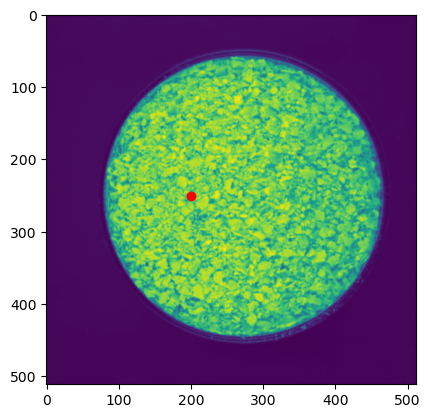

In [18]:
i = 4

k = model.predict([cubes[i][200, 250, :]])
print(folders[i])
print(folders[nums.index(k)])

plt.imshow(cubes[i][:,:,100])
plt.plot(200,250, 'ro')
plt.show()

In [20]:
print(model.intercept_)
print(len(model.coef_))

[  8.60232845   9.54888778   6.95963522  14.94715618  -0.5412225
   3.49753024  -5.33815121   6.26248002  -0.63219345   8.04361516
  -4.88541948   4.51889968  18.64114957   7.87614829  14.062575
  -2.4460208    2.54333253  12.90074441  -2.79983549  -0.63563951
  -5.90406653 -50.34585251 -44.87608104]
23


# K-nearest neighbours

In [33]:
model = KNeighborsClassifier()

param_grid = {'n_neighbors':range(2, 10), 'algorithm':['auto', 'ball_tree', 'kd_tree', 'brute'], 'weights':['uniform', 'distance']}

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, verbose=True)
# grid_search.fit(X_train, y_train)

# print("best accuracy", grid_search.best_score_)
# print(grid_search.best_estimator_)

Accuracy: 0.8003478260869565
              precision    recall  f1-score   support

         035       0.56      0.61      0.58       270
         036       0.53      0.55      0.54       253
         037       0.58      0.55      0.57       218
         038       0.68      0.67      0.68       254
         040       0.64      0.82      0.72       231
         041       0.78      0.60      0.68       259
         042       0.94      0.98      0.96       275
         043       0.76      0.88      0.81       248
         044       0.97      0.90      0.94       259
         057       0.88      0.96      0.92       262
         058       0.72      0.70      0.71       257
         059       0.87      0.94      0.90       256
         060       0.79      0.72      0.76       234
         061       0.92      0.81      0.86       231
         062       0.83      0.67      0.74       252
         063       0.76      0.69      0.72       238
         064       0.80      0.81      0.81       24

kitchenday2/puolikarkea_vehnajauho/
kitchenday2/kookoshiutale/


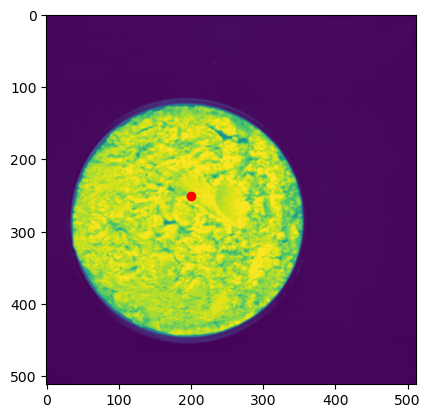

In [45]:
i = 17

k = model.predict([cubes[i][200, 250, :]])
print(folders[i])
print(folders[nums.index(k)])

plt.imshow(cubes[i][:,:,100])
plt.plot(200,250, 'ro')
plt.show()

# SVC

In [71]:
model = SVC(kernel='linear', random_state=4)

param_grid = {'kernel':['linear', 'poly', 'rbf', 'sigmoid'], 'shrinking':[True, False]}

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, verbose=True)
# grid_search.fit(X_train, y_train)

# print("best accuracy", grid_search.best_score_)
# print(grid_search.best_estimator_)

Accuracy: 0.9506086956521739
              precision    recall  f1-score   support

         035       0.97      0.97      0.97       270
         036       0.93      0.91      0.92       253
         037       0.94      0.98      0.96       218
         038       0.92      0.95      0.93       254
         040       0.95      0.97      0.96       231
         041       0.98      0.95      0.96       259
         042       1.00      1.00      1.00       275
         043       1.00      1.00      1.00       248
         044       1.00      0.99      1.00       259
         057       1.00      1.00      1.00       262
         058       0.92      0.89      0.91       257
         059       0.97      0.98      0.97       256
         060       0.95      0.89      0.92       234
         061       0.96      0.92      0.94       231
         062       0.91      0.92      0.92       252
         063       0.89      0.93      0.91       238
         064       0.83      0.90      0.86       24

kitchenday2/sampylajauho/
kitchenday2/maizena/


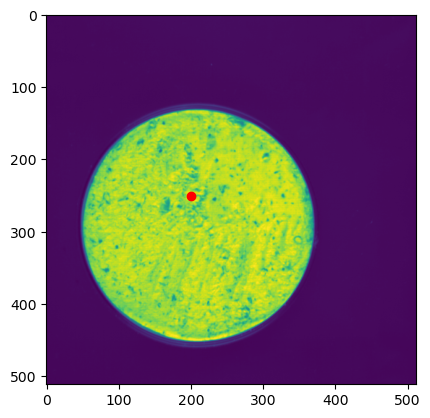

In [93]:
i = 19

k = model.predict([cubes[i][200, 250, :]])
print(folders[i])
print(folders[nums.index(k)])

plt.imshow(cubes[i][:,:,100])
plt.plot(200,250, 'ro')
plt.show()

# Random forest <sup>(Very slow)</sup>

In [ ]:
model = RandomForestClassifier(random_state=4, n_estimators=50)

param_grid = {'criterion':['gini', 'entropy', 'log_loss'], 'max_depth':[8, 10, 12], 'min_samples_leaf':[2, 3, 5]}

# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, verbose=True)
grid_search.fit(X_train, y_train)

print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
best accuracy 0.8067246376811597
RandomForestClassifier(criterion='entropy', max_depth=12, min_samples_leaf=2,
                       n_estimators=50, random_state=4)


# Naive Bayes

In [18]:
model = GaussianNB()

param_grid = {}

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.3071304347826087
              precision    recall  f1-score   support

         035       0.34      0.18      0.23       270
         036       0.36      0.33      0.34       253
         037       0.25      0.00      0.01       218
         038       0.22      0.29      0.25       254
         040       0.37      0.53      0.43       231
         041       0.37      0.37      0.37       259
         042       0.41      0.70      0.51       275
         043       0.25      0.28      0.26       248
         044       0.32      0.23      0.27       259
         057       0.30      0.34      0.32       262
         058       0.28      0.24      0.26       257
         059       0.38      0.87      0.53       256
         060       0.27      0.21      0.24       234
         061       0.12      0.05      0.07       231
         062       0.00      0.00      0.00       252
         063       0.00      0.00      0.00       238
         064       0.15      0.37      0.21       24

# Gradient boosting <sup>(Very slow)</sup>

In [24]:
model = GradientBoostingClassifier(random_state=4, n_estimators=100)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8224347826086956
              precision    recall  f1-score   support

         035       0.66      0.73      0.69       270
         036       0.63      0.61      0.62       253
         037       0.63      0.60      0.61       218
         038       0.76      0.78      0.77       254
         040       0.66      0.73      0.69       231
         041       0.76      0.70      0.73       259
         042       0.99      0.95      0.97       275
         043       0.89      0.95      0.92       248
         044       0.95      0.96      0.95       259
         057       0.90      0.98      0.94       262
         058       0.79      0.68      0.73       257
         059       0.88      0.90      0.89       256
         060       0.88      0.82      0.85       234
         061       0.91      0.78      0.84       231
         062       0.79      0.74      0.76       252
         063       0.76      0.74      0.75       238
         064       0.83      0.76      0.79       24

# Neural networks

### TensorFlow

In [138]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(shape=[204]))
#model.add(tf.keras.layers.Dense(200, activation='relu'))
model.add(tf.keras.layers.Dense(100, activation='relu'))
model.add(tf.keras.layers.Dense(50, activation='relu'))
#model.add(tf.keras.layers.Dropout(rate=0.1))
#model.add(tf.keras.layers.Conv1D(64, 3, activation='relu'))
#model.add(tf.keras.layers.Flatten())
#model.add(tf.keras.layers.Dense(30, activation='relu'))
model.add(tf.keras.layers.Dense(23, activation='softmax'))

In [139]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_58 (Dense)                │ (None, 100)            │        20,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 23)             │         1,173 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,723 (104.39 KB)

 Trainable params: 26,723 (104.39 KB)

 Non-trainable params: 0 (0.00 B)

In [140]:
model.fit(X_train, y_train, epochs=200, verbose=0)

I0000 00:00:1785847085.901680 1673605 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6369844__.13
I0000 00:00:1785847087.908504 1673605 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6369844__.13


In [141]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")

180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9450 - loss: 0.1711
Test accuracy: 0.9450435042381287


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
kitchen/basmatiriisi/
kitchenday2/sampylajauho/
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
kitchen/kaurahiutale1min/
kitchenday2/sampylajauho/
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
kitchen/kuivahiiva/
kitchenday2/sampylajauho/
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
kitchen/kvinoa/
kitchenday2/sampylajauho/
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
kitchen/ohrahiutale_kasittelematon/
kitchenday2/sampylajauho/
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
kitchen/psyllium/
kitchenday2/sampylajauho/
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
kitchen/puuroriisi/
kitchenday2/sampylajauho/
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
kitchen/rikottu_ohrasuurimo/
kitchenday2/sampylajauho/
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
kitchen/seesaminsiemen/
kitchenday2/puolikarkea_vehnajauho/
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
kitchenday2/durumvehna/
kitchenday2/puolikarkea_vehnajauho/
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
kitchenday2/jodioitu_suola/
kitchenday2/leivinjauhe/
1/1 ━━━━━━━━━

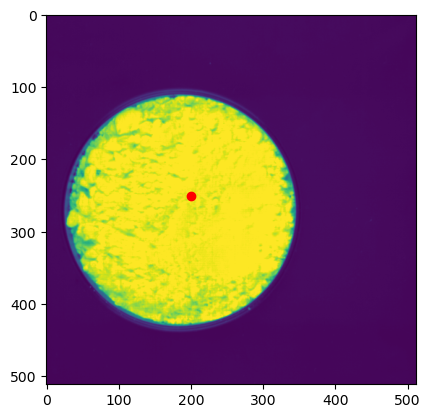

In [142]:
aa = 0
for i in range(0, 23):
    k = model.predict(tf.constant([cubes[i][200, 300, :]]))
    print(folders[i])
    print(folders[int(np.argmax(k))])
    if folders[i] == folders[int(np.argmax(k))]:
        aa += 1

print(aa)
plt.imshow(cubes[i][:,:,100])
plt.plot(200,250, 'ro')
plt.show()